# Análisis de series temporales
En el presente cuadernillo se hallan los modelos de análisis de series temporales, hecho en `R`, para el caso de análisis de este TFG. El análisis completo de los datos solo se realizará en este cuadernillo, mientras que en el cuadernillo <a href="Análisis en Python.ipynb" target="_blank"><code>Análisis en Python.ipynb</code></a> solo se replica el modelo y se realiza la comparación sintáctica para usarse como base para el uso del paquete `pyrcore` en la última parte del TFG.

**Caso de estudio**: Análisis temporal de las series de producción de gas de esquisto en varios sitios de EEUU para el periodo enero de 2000 a agosto de 2022 (2000.01-2022.08).

In [1]:
# Comprobar si se han instalado los siguientes paquetes:
# DBI
if (!require("DBI")){
    # En caso contrario, instalar y cargar
    install.packages("DBI")
    library(DBI)
}

# RSQLite
if (!require("RSQLite")){
    # En caso contrario, instalar y cargar
    install.packages("RSQLite")
    library(RSQLite)
}

# ggplot2
if (!require("ggplot2")){
    # En caso contrario, instalar y cargar
    install.packages("ggplot2")
    library(ggplot2)
}

# forecast
if (!require("forecast")){
    # En caso contrario, instalar y cargar
    install.packages("forecast")
    library(forecast)
}

Cargando paquete requerido: DBI

Cargando paquete requerido: RSQLite

Cargando paquete requerido: ggplot2

Cargando paquete requerido: forecast



## Análisis de series temporales univariantes
Análisis temporal de las series de producción de gas de esquisto en varios sitios de EEUU para el periodo enero de 2000 a agosto de 2022 (2000.01-2022.08).

### Importación de datos
Extraer los datos necesarios del fichero *DataBase* `Base de datos TFG.db` en forma de serie temporal (`ts()`).

In [2]:
# Conectar a la base de datos
conn <- dbConnect(RSQLite::SQLite(), "..\\datasets\\Base de datos TFG.db")
# Importar datos desde la base de datos
gas <- dbGetQuery(conn, "SELECT * FROM Esquisto")
# Retirar la última columna, que no es una serie temporal
gas <- gas[-length(colnames(gas))]
# Desconectar de la base de datos
dbDisconnect(conn)
# Estadísticos básicos
summary(gas)
# Previsualizar datos
head(gas)

        Date      Barnett (TX)    Haynesville (LA & TX)
 Length   :272   Min.   :0.1337   Min.   : 0.07663     
 N.unique :272   1st Qu.:1.2412   1st Qu.: 0.12348     
 N.blank  :  0   Median :2.4836   Median : 3.72571     
 Min.nchar: 19   Mean   :2.6063   Mean   : 3.78632     
 Max.nchar: 19   3rd Qu.:4.1608   3rd Qu.: 6.62490     
                 Max.   :5.2176   Max.   :13.50900     
 Marcellus (PA, WV, OH & NY) Permian (TX & NM) Utica (OH, PA & WV)
 Min.   :3.238e-04           Min.   : 0.6047   Min.   :0.0001603  
 1st Qu.:9.216e-04           1st Qu.: 0.7047   1st Qu.:0.0005614  
 Median :3.048e+00           Median : 1.1195   Median :0.0015628  
 Mean   :8.408e+00           Mean   : 3.5309   Mean   :1.9919494  
 3rd Qu.:1.692e+01           3rd Qu.: 4.3446   3rd Qu.:4.2460048  
 Max.   :2.646e+01           Max.   :14.4236   Max.   :8.2354328  
 Woodford (OK)      Bakken (ND & MT)  Niobrara-Codell (CO & WY)
 Min.   :0.007737   Min.   :0.01088   Min.   :0.2482           
 1st Qu.:0.

,Date,Barnett (TX),Haynesville (LA & TX),"Marcellus (PA, WV, OH & NY)",Permian (TX & NM),"Utica (OH, PA & WV)",Woodford (OK),Bakken (ND & MT),Niobrara-Codell (CO & WY),Mississippian (OK)
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2000-01-01 00:00:00,0.1337097,0.1410044,0.0008449676,0.6320696,0.0002948456,0.009290342,0.01350129,0.2571736,0.6870402
2,2000-02-01 00:00:00,0.1395305,0.1408326,0.0008446552,0.6423939,0.0002948455,0.008526182,0.01311571,0.2585000,0.6942075
3,2000-03-01 00:00:00,0.1505652,0.1402995,0.0008450582,0.6653018,0.0002948456,0.008625523,0.01286715,0.2585993,0.7042231
4,2000-04-01 00:00:00,0.1598422,0.1429651,0.0008437730,0.6800481,0.0002948454,0.008809750,0.01332514,0.2537982,0.6892704
5,2000-05-01 00:00:00,0.1639615,0.1436432,0.0008432027,0.7015090,0.0002948455,0.008715563,0.01284257,0.2530226,0.7242722
6,2000-06-01 00:00:00,0.1758135,0.1347880,0.0008413305,0.7060018,0.0002948454,0.008585956,0.01289556,0.2523684,0.7196170


In [3]:
# Establecer las fechas como los nombres de las filas
rownames(gas) <- gas$Date # gas[, 1]
# Quitar las fechas del data.frame
gas <- gas[-1]
# Previsualizar de nuevo
head(gas)

,Barnett (TX),Haynesville (LA & TX),"Marcellus (PA, WV, OH & NY)",Permian (TX & NM),"Utica (OH, PA & WV)",Woodford (OK),Bakken (ND & MT),Niobrara-Codell (CO & WY),Mississippian (OK)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2000-01-01 00:00:00,0.1337097,0.1410044,0.0008449676,0.6320696,0.0002948456,0.009290342,0.01350129,0.2571736,0.6870402
2000-02-01 00:00:00,0.1395305,0.1408326,0.0008446552,0.6423939,0.0002948455,0.008526182,0.01311571,0.2585000,0.6942075
2000-03-01 00:00:00,0.1505652,0.1402995,0.0008450582,0.6653018,0.0002948456,0.008625523,0.01286715,0.2585993,0.7042231
2000-04-01 00:00:00,0.1598422,0.1429651,0.0008437730,0.6800481,0.0002948454,0.008809750,0.01332514,0.2537982,0.6892704
2000-05-01 00:00:00,0.1639615,0.1436432,0.0008432027,0.7015090,0.0002948455,0.008715563,0.01284257,0.2530226,0.7242722
2000-06-01 00:00:00,0.1758135,0.1347880,0.0008413305,0.7060018,0.0002948454,0.008585956,0.01289556,0.2523684,0.7196170


Dado que se replica este trabajo de la asignatura *Data Modelling: Econometría*, se ha de elegir una de la series. En este caso, elegiré la segunda serie temporal, del grupo *Haynesville (LA & TX)*.

In [4]:
# Extraer Haynesville (LA & TX) como serie temporal
gas <- ts( # Función "ts()" para creación de series temporales
    gas[2], # Columna de "Haynesville (LA & TX)"
    start = 2000, # Comienza en enero del año 2000
    frequency = 12 # Datos mensuales
)
# Visualizar serie temporal
gas

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,0.14100444,0.14083257,0.14029952,0.14296514,0.14364317,0.13478803,0.14062804,0.14072152,0.13925923,0.14130991,0.13977072,0.13621970
2001,0.13019526,0.13045837,0.13165325,0.13296215,0.13750709,0.13526552,0.13846725,0.13685378,0.13044221,0.13037297,0.13195884,0.12755737
2002,0.12710717,0.13040518,0.12796394,0.13028856,0.13129055,0.13324875,0.13368979,0.12809680,0.12837576,0.10567040,0.12570809,0.12395437
2003,0.11991764,0.12054739,0.11863175,0.11404835,0.11270857,0.10823752,0.10770097,0.10414172,0.10648503,0.10327376,0.10186782,0.10130473
2004,0.09665556,0.09586970,0.09539910,0.09489545,0.09570626,0.09268865,0.09921716,0.09936309,0.10370114,0.10078356,0.10045147,0.09473671
2005,0.09741047,0.09606957,0.09233973,0.09474918,0.09392986,0.09221106,0.09319494,0.09324831,0.08387715,0.09054162,0.08959976,0.08620625
2006,0.08494535,0.08431362,0.08453369,0.08458567,0.08436315,0.08160889,0.08224000,0.08189414,0.08113520,0.08117429,0.08183197,0.08189278
2007,0.08259116,0.08179211,0.08033169,0.07662893,0.07910241,0.07762301,0.07703403,0.07752959,0.07895730,0.07961723,0.08401071,0.08602544
2008,0.08811638,0.08466262,0.08665762,0.10213246,0.10644900,0.10871371,0.12204141,0.13234210,0.15983544,0.21095199,0.26785825,0.36691669
2009,0.41560733,0.49740892,0.59620233,0.75038789,0.89218134,1.05619666,1.19186579,1.39867612,1.59146907,1.86456972,2.13137234,2.18435208


### Análisis clásico
Análisis clásico de series temporales univariantes.

#### Identificación del esquema
En primer lugar, se realiza un gráfico media-desviación típica para identificar si la serie sigue un esquema aditivo o multiplicativo.

In [5]:
# Hallar promedios y desviaciones típicas anuales
medias <- c(aggregate(gas, nfrequency = 1, FUN = mean))
desviaciones <- c(aggregate(gas, nfrequency = 1, FUN = sd))

# Unificar en un data.frame
media_desviacion <- data.frame(
    Media = medias, # Columna "Media"
    Desviación_típica = desviaciones, # Columna "Desviación_típica"
    row.names = 2000:2021 # Nombres de las filas (solo filas completas)
)
media_desviacion

,Media,Desviación_típica
,<dbl>,<dbl>
2000,0.14012016,0.002493095
2001,0.13280784,0.003438250
2002,0.12714995,0.007350215
2003,0.10990544,0.007069660
2004,0.09745566,0.003203890
2005,0.09194816,0.003904158
2006,0.08287656,0.001513230
2007,0.08010363,0.002958074
2008,0.15305647,0.087250966


In [6]:
# Ajustar tamaño de la ventana del dispositivo de gráficos
options(repr.plot.width = 10, repr.plot.height = 7.5)

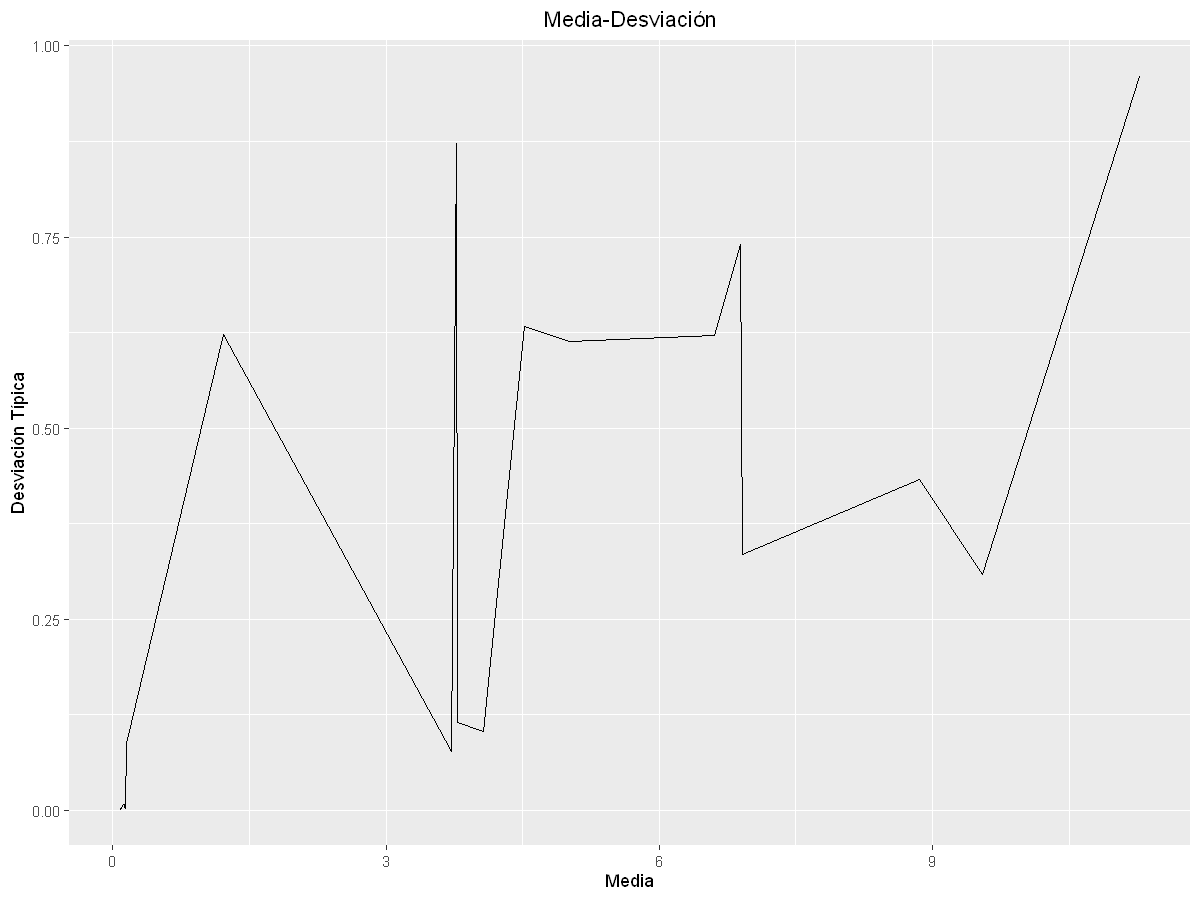

In [7]:
# Representar la media frente a la desviación típica anuales
ggplot(
    media_desviacion, # data.frame con promedios y desviaciones anuales
    aes(x = Media, y= Desviación_típica) # Ejes
) + geom_line() +
labs(
    title = "Media-Desviación",
    y = "Desviación Típica"
) +
theme(plot.title = element_text(hjust = 0.5))
ggsave("..\\Gráficos\\Media-Desviación.png", width = 10, height = 7.5)

Dado que la desviación típica varía a medida que lo hace la media, se concluye que la serie sigue un esquema **multiplicativo**.

#### Tendencia
Se representan gráficamente los datos para comprobar si existe una tendencia y, en tal caso, su forma.

pdf 
  2

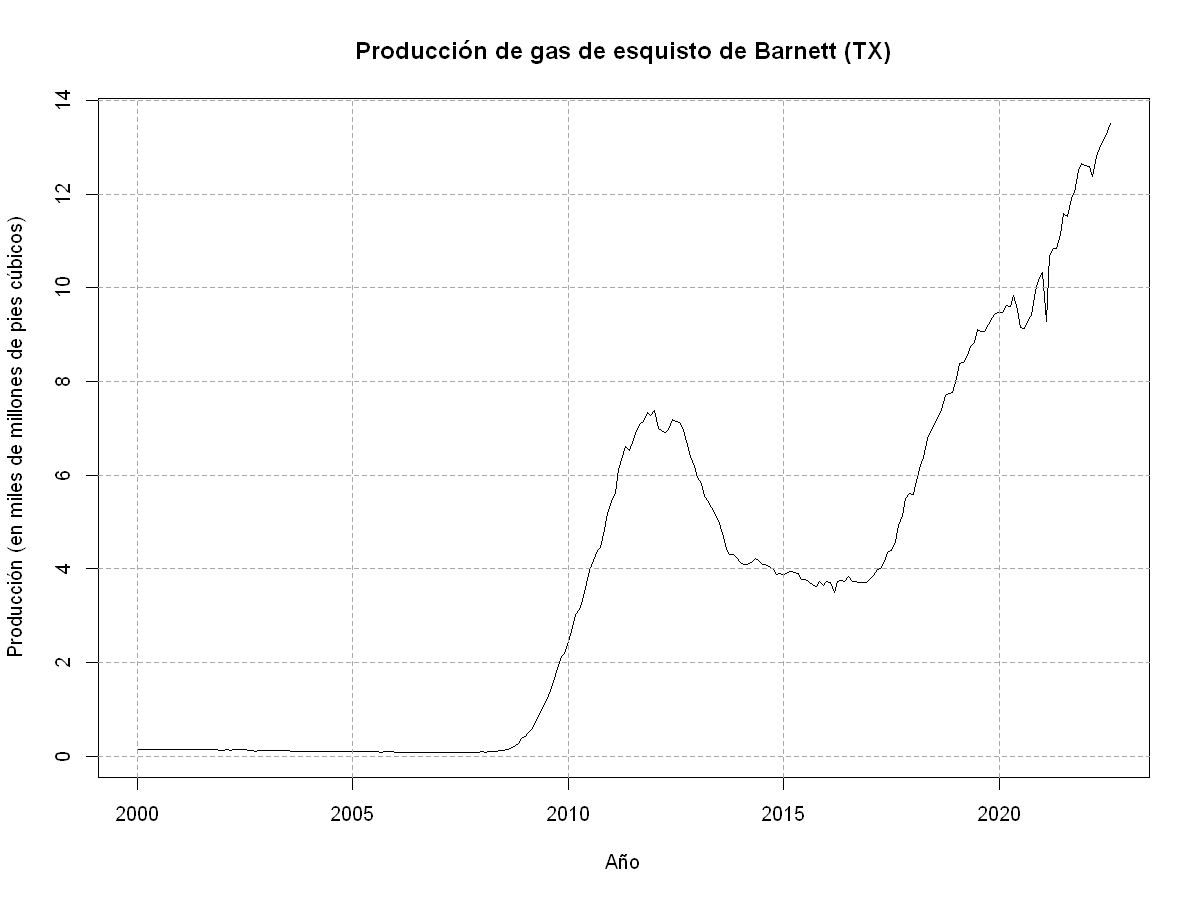

In [8]:
# Cambiar fondo a blanco
par(bg = "white")
# Generar gráfico
plot(
  gas, # Datos
  main = "Producción de gas de esquisto de Barnett (TX)", # Título
  xlab = "Año", # Etiqueta eje X
  ylab = "Producción (en miles de millones de pies cúbicos)" # Etiqueta eje Y
)
# Cuadrícula
grid(col = "darkgray", lty = "dashed")

# Almacenar gráfico
grafico <- recordPlot()

# Preparar ruta y tamaño para guardar el gráfico
png("..\\Gráficos\\Serie temporal.png", width = 1000, height = 750)

# Reproducir gráfico para guardarlo
replayPlot(grafico)

# Cerrar archivo .png
dev.off()

# Liberar espacio en memoria borrando la variable gráfico
rm(grafico)

Parece observarse una tendencia cuadrática (aproximadamente).

#### Descomposición
Se procede a la descomposición en la tendencia y componente estacional.

In [9]:
# Descomponer serie temporal
descomposicion <- decompose(gas, type = "multiplicative")
# Obtener tendencia
tendencia <- descomposicion$trend
# Cálculo de Índices de Variación Estacional (IVEs)
ives <- tapply(descomposicion$seasonal, cycle(descomposicion$seasonal), mean)
# Mostrar tendencia e IVEs
tendencia
print(ives)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,NA,NA,NA,NA,NA,NA,0.13966978,0.13878714,0.13799462,0.13721757,0.13654511,0.13630933
2001,0.13623920,0.13598801,0.13545948,0.13463640,0.13385520,0.13316877,0.13267917,0.13254828,0.13239234,0.13212722,0.13175680,0.13141375
2002,0.13113065,0.13056672,0.13011574,0.12900037,0.12771065,0.12730007,0.12685038,0.12614008,0.12534050,0.12427498,0.12282405,0.12100767
2003,0.11888267,0.11680167,0.11489143,0.11387946,0.11278625,0.11084917,0.10893618,0.10693869,0.10494243,0.10317637,0.10166990,0.10031360
2004,0.09931224,0.09875964,0.09844453,0.09822478,0.09806201,0.09772932,0.09748711,0.09752689,0.09740775,0.09727418,0.09719407,0.09710015
2005,0.09682932,0.09632362,0.09524283,0.09399009,0.09311118,0.09230359,0.09142878,0.09041957,0.08960448,0.08885575,0.08803366,0.08719329
2006,0.08629508,0.08536553,0.08477819,0.08427364,0.08355968,0.08305629,0.08277847,0.08257532,0.08229517,0.08178856,0.08123783,0.08085255
2007,0.08046956,0.08007079,0.07979818,0.07964256,0.07966846,0.07993144,0.08033385,0.08068367,0.08106686,0.08239309,0.08459517,0.08703006
2008,0.09020081,0.09435998,0.10001375,0.10885596,0.12198855,0.14135267,0.16670193,0.19754515,0.23597394,0.28421561,0.34396510,0.41618241
2009,0.50023688,0.59757681,0.70999213,0.83854427,0.98509143,1.13846432,1.29869106,1.47319211,1.66438830,1.86428278,2.06438859,2.27493451


        1         2         3         4         5         6         7         8 
0.9983317 0.9904032 0.9955614 1.0031371 1.0101130 0.9999486 1.0039129 0.9974105 
        9        10        11        12 
0.9949582 0.9915544 1.0108469 1.0038223 


Los **Í**ndices de **V**ariación **E**stacional (**IVE**s) son extremadamente cercanos a 1, por lo que no hay componente estacional significativa.

Aquí concluye el análisis clásico y se da paso a la metodología *Box-Jenkins*.

### Metodología *Box-Jenkins*

#### Estudiar la estacionariedad de la serie

##### Media

En el análisis clásico pareció observarse una tendencia cuadrática. Se procede a la comprobación de la tendencia.

In [10]:
# Usando el vector "medias"
medias

[1]  0.14012016  0.13280784  0.12714995  0.10990544  0.09745566  0.09194816
 [7]  0.08287656  0.08010363  0.15305647  1.21419080  3.76993606  6.60238962
[13]  6.91585857  5.01530779  4.07037246  3.78982508  3.71388108  4.52293596
[19]  6.89141987  8.85574341  9.55534665 11.27833539

pdf 
  2

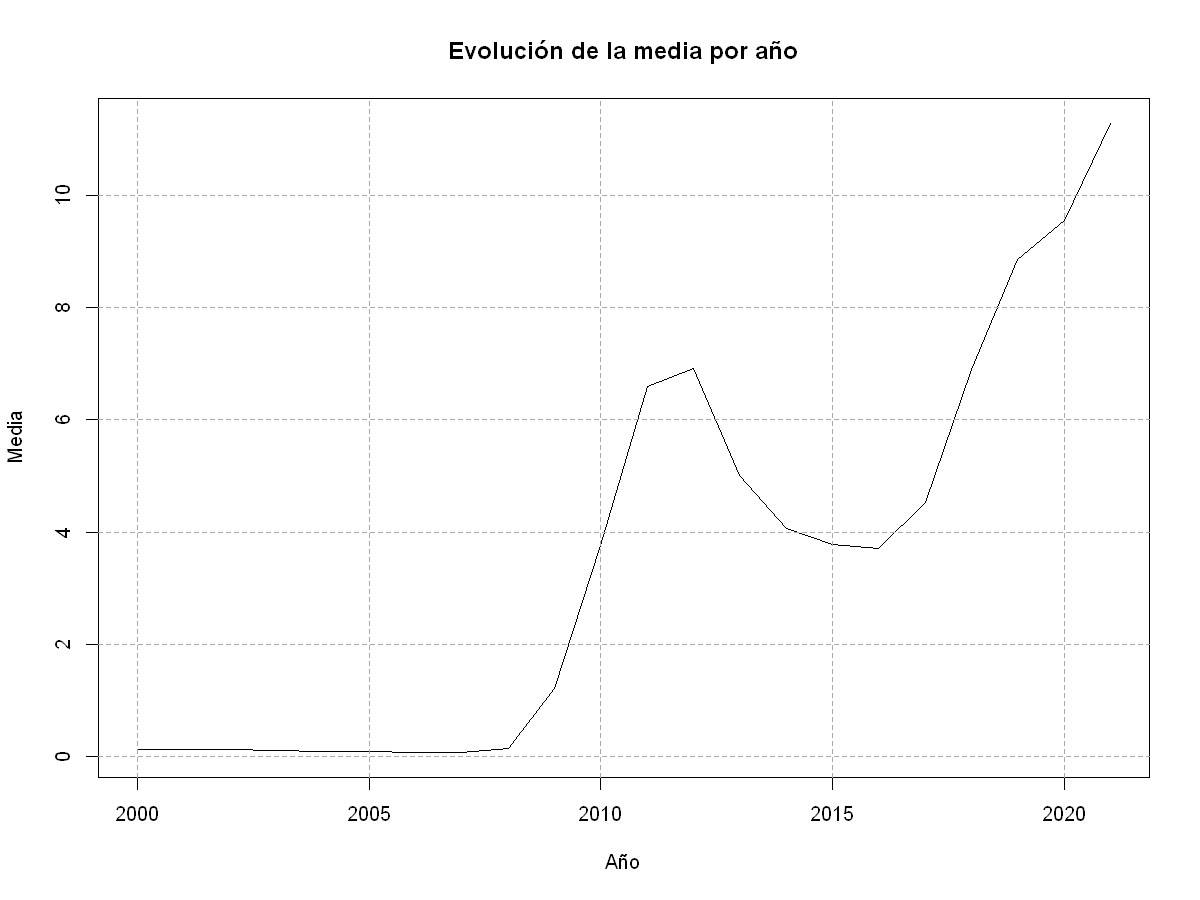

In [11]:
# Representar, mediante un diagrama de líneas, los promedios anuales
par(bg = "white")
plot(
  2000:2021, medias,
  type = "l",
  main = "Evolución de la media por año",
  xlab = "Año",
  ylab = "Media"
)
grid(col = "darkgray", lty = "dashed")
grafico <- recordPlot()
png("..\\Gráficos\\Media-Tiempo.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

En efecto, se observa una tendencia cuadrática (de nuevo, aproximadamente).

La serie **no es estacionaria en media** y, como la tendencia es cuadrática, requerirá aplicar **dos diferencias lineales**.

In [12]:
# Comprobar diferencias
ndiffs(gas) # Lineales
nsdiffs(gas) # Estacionales

[1] 2

[1] 0

##### Varianza

Representar gráficamente la evolución de la varianza respecto al tiempo para comprobar si es <ins>heterocedástica</ins> (no estacionaria en varianza) u <ins>homocedástica</ins> (estacionaria en varianza).

In [13]:
# Usando el vector desviaciones
desviaciones ^ 2

[1] 6.215523e-06 1.182156e-05 5.402565e-05 4.998009e-05 1.026491e-05
 [6] 1.524245e-05 2.289865e-06 8.750201e-06 7.612731e-03 3.872261e-01
[11] 7.603249e-01 3.852971e-01 1.120775e-01 3.769571e-01 1.072040e-02
[16] 1.320717e-02 5.955244e-03 4.011500e-01 5.488870e-01 1.871370e-01
[21] 9.566216e-02 9.212490e-01

pdf 
  2

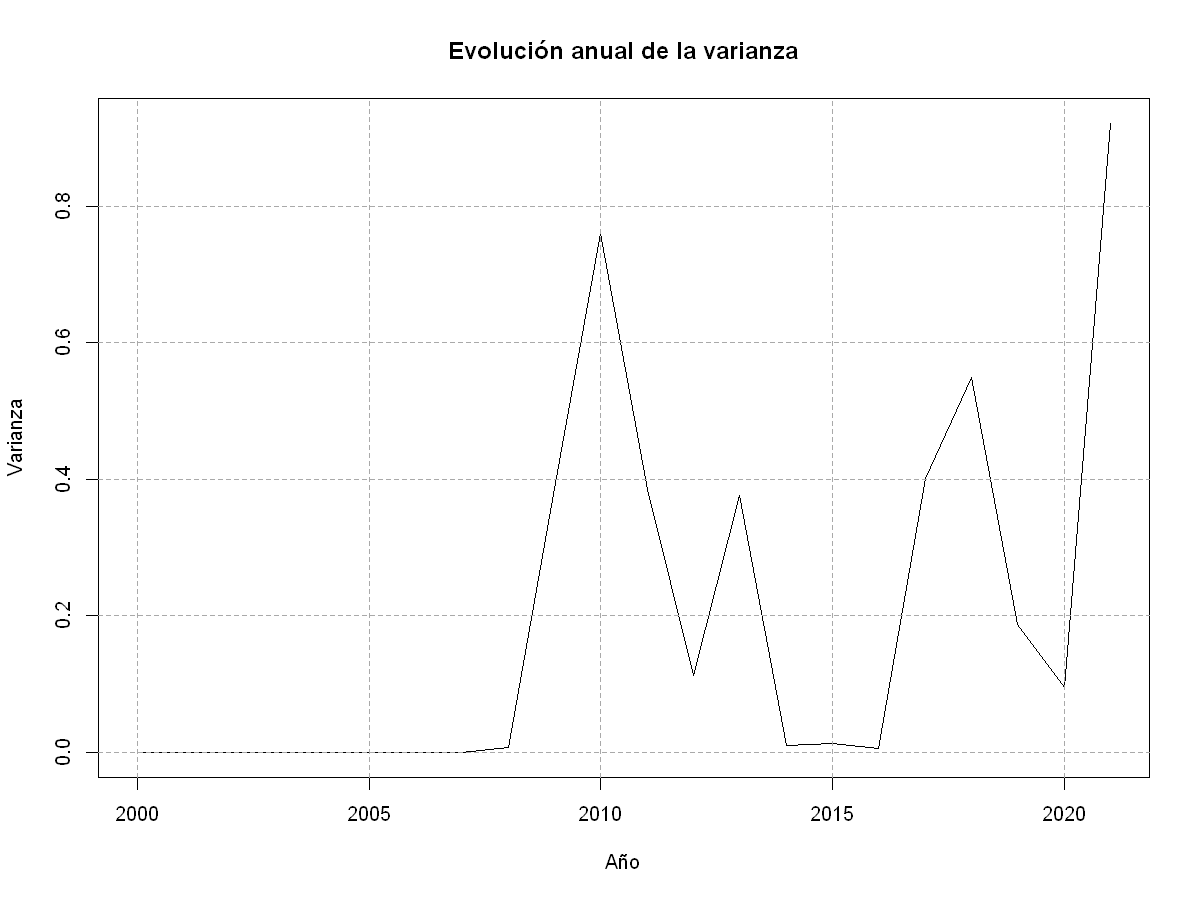

In [14]:
# Representar, mediante un diagrama de líneas, las varianzas anuales
par(bg = "white")
plot(
  2000:2021, desviaciones ^ 2,
  type = "l",
  main = "Evolución anual de la varianza",
  xlab = "Año",
  ylab = "Varianza"
)
grid(col = "darkgray", lty = "dashed")
grafico <- recordPlot()
png("..\\Gráficos\\Varianza-Tiempo.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

La varianza no es constante a lo largo del tiempo. Sin embargo, dado que no existe un patrón en las variaciones de la varianza, se considera que estas fluctuaciones se deben a elementos accidentales.

**<ins>NO</ins>** se requiere **transformación logarítmica**. El cálculo de $\lambda$ para estabilización de la varianza no ha sido aprendido durante el curso. Afortunadamente, existen funciones para integrar su uso en la modelización como, por ejemplo, la transformación de Box-Cox.

##### Componente estacional
Dado que no hay componente estacional significativa, no se requiren transformaciones estacionales.

#### Transformación de la serie

##### Separación

In [15]:
# Conjunto de entrenamiento
train <- window(gas, end = c(2022, 3))

# Conjunto de prueba
test <- window(gas, start = c(2022, 4))

# Visualizar
train
test

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,0.14100444,0.14083257,0.14029952,0.14296514,0.14364317,0.13478803,0.14062804,0.14072152,0.13925923,0.14130991,0.13977072,0.13621970
2001,0.13019526,0.13045837,0.13165325,0.13296215,0.13750709,0.13526552,0.13846725,0.13685378,0.13044221,0.13037297,0.13195884,0.12755737
2002,0.12710717,0.13040518,0.12796394,0.13028856,0.13129055,0.13324875,0.13368979,0.12809680,0.12837576,0.10567040,0.12570809,0.12395437
2003,0.11991764,0.12054739,0.11863175,0.11404835,0.11270857,0.10823752,0.10770097,0.10414172,0.10648503,0.10327376,0.10186782,0.10130473
2004,0.09665556,0.09586970,0.09539910,0.09489545,0.09570626,0.09268865,0.09921716,0.09936309,0.10370114,0.10078356,0.10045147,0.09473671
2005,0.09741047,0.09606957,0.09233973,0.09474918,0.09392986,0.09221106,0.09319494,0.09324831,0.08387715,0.09054162,0.08959976,0.08620625
2006,0.08494535,0.08431362,0.08453369,0.08458567,0.08436315,0.08160889,0.08224000,0.08189414,0.08113520,0.08117429,0.08183197,0.08189278
2007,0.08259116,0.08179211,0.08033169,0.07662893,0.07910241,0.07762301,0.07703403,0.07752959,0.07895730,0.07961723,0.08401071,0.08602544
2008,0.08811638,0.08466262,0.08665762,0.10213246,0.10644900,0.10871371,0.12204141,0.13234210,0.15983544,0.21095199,0.26785825,0.36691669
2009,0.41560733,0.49740892,0.59620233,0.75038789,0.89218134,1.05619666,1.19186579,1.39867612,1.59146907,1.86456972,2.13137234,2.18435208


,Apr,May,Jun,Jul,Aug
2022,12.80273,12.97575,13.15112,13.32886,13.50900


##### Diferencia lineal
Fórmula matemática:
$\Delta y_t = y_t - y_{t-1}$

$\Delta^d y_t = y_t - y_{t-1} - y_{t-2} - ... - y_{t-d}$

In [16]:
# DOS diferencias lineales
train <- diff(train, differences = 2)
train

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,,,-3.611734e-04,3.198661e-03,-1.987582e-03,-9.533179e-03,1.469515e-02,-5.746531e-03,-1.555765e-03,3.512967e-03,-3.589875e-03,-2.011824e-03
2001,-2.473419e-03,6.287541e-03,9.317730e-04,1.140294e-04,3.236028e-03,-6.786506e-03,5.443303e-03,-4.815207e-03,-4.798095e-03,6.342333e-03,1.655107e-03,-5.987343e-03
2002,3.951272e-03,3.748207e-03,-5.739243e-03,4.765864e-03,-1.322642e-03,9.562203e-04,-1.517165e-03,-6.034026e-03,5.871945e-03,-2.298432e-02,4.274306e-02,-2.179141e-02
2003,-2.283014e-03,4.666482e-03,-2.545385e-03,-2.667761e-03,3.243620e-03,-3.131277e-03,3.934506e-03,-3.022706e-03,5.902562e-03,-5.554577e-03,1.805331e-03,8.428514e-04
2004,-4.086080e-03,3.863306e-03,3.152600e-04,-3.304823e-05,1.314453e-03,-3.828413e-03,9.546125e-03,-6.382584e-03,4.192116e-03,-7.255624e-03,2.585488e-03,-5.382675e-03
2005,8.388522e-03,-4.014659e-03,-2.388936e-03,6.139281e-03,-3.228763e-03,-8.994790e-04,2.702674e-03,-9.305067e-04,-9.424521e-03,1.603562e-02,-7.606322e-03,-2.451655e-03
2006,2.132612e-03,6.291697e-04,8.517970e-04,-1.680806e-04,-2.745096e-04,-2.531739e-03,3.385379e-03,-9.769804e-04,-4.130782e-04,7.980309e-04,6.185921e-04,-5.968712e-04
2007,6.375715e-04,-1.497431e-03,-6.613702e-04,-2.242348e-03,6.176255e-03,-3.952893e-03,8.904255e-04,1.084537e-03,9.321571e-04,-7.677805e-04,3.733545e-03,-2.378752e-03
2008,7.621336e-05,-5.544698e-03,5.448763e-03,1.347983e-02,-1.115829e-02,-2.051827e-03,1.106298e-02,-3.027003e-03,1.719265e-02,2.362321e-02,5.789705e-03,4.215217e-02
2009,-5.036779e-02,3.311095e-02,1.699183e-02,5.539215e-02,-1.239211e-02,2.222187e-02,-2.834619e-02,7.114121e-02,-1.401738e-02,8.030770e-02,-6.298034e-03,-2.138229e-01


#### Identificación del modelo

##### Correlogramas

pdf 
  2

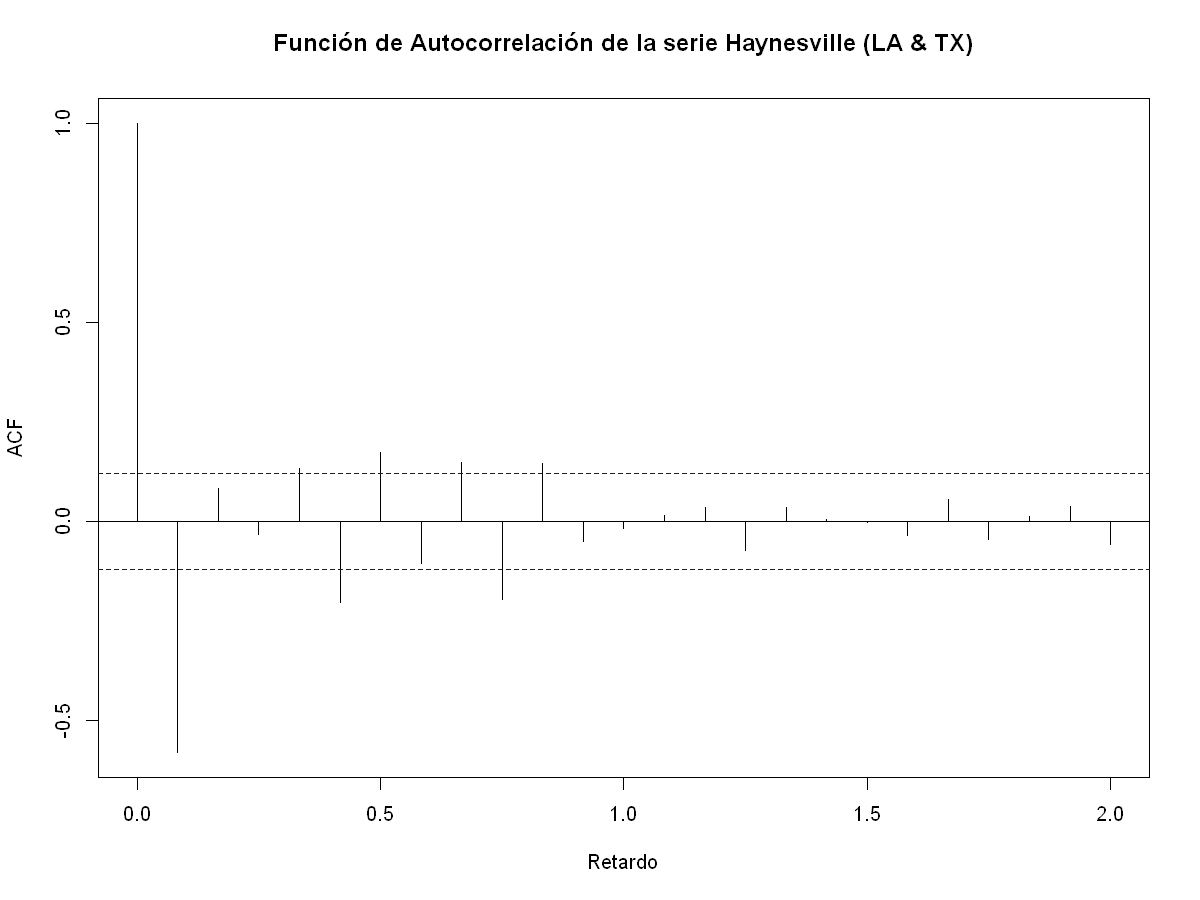

In [17]:
# Función de Autocorrelación
par(bg = "white")
acf(
    train,
    main = "Función de Autocorrelación de la serie Haynesville (LA & TX)",
    xlab = "Retardo"
)
grafico <- recordPlot()
png("..\\Gráficos\\ACF.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

pdf 
  2

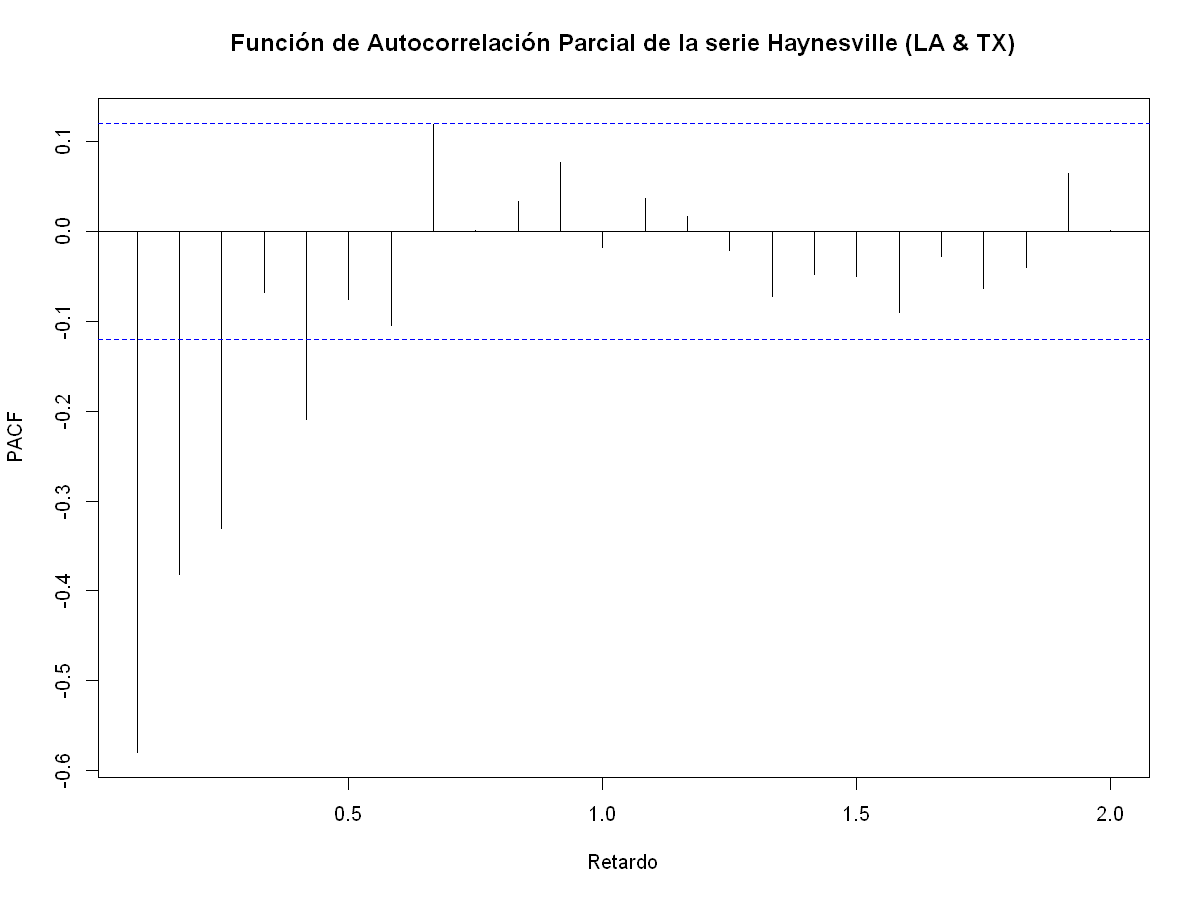

In [18]:
# Función de Autocorrelación Parcial
par(bg = "white")
pacf(
    train,
    main = "Función de Autocorrelación Parcial de la serie Haynesville (LA & TX)",
    xlab = "Retardo", ylab = "PACF"
)
grafico <- recordPlot()
png("..\\Gráficos\\PACF.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

* **AR(p=1)**
* **Dos diferencias lineales (d=2)**
* **MA(q=2)**

Por tanto, el modelo es un **ARIMA(1,2,2)** (`p = 1`, `d = 2`, `q = 2`).

#### Estimación de los coeficientes de los modelos

Se ajusta un modelo ARIMA a la **serie** aplicando transformaciones.

In [19]:
# Reconstruir conjunto de entrenamiento
train <- window(gas, end = end(train))

In [20]:
# Modelo MA(2)
modelo <- arima(train, order = c(1, 2, 2))
modelo


Call:
arima(x = train, order = c(1, 2, 2))

Coefficients:
         ar1      ma1     ma2
      0.5319  -1.5997  0.7378
s.e.  0.1100   0.0954  0.0968

sigma^2 estimated as 0.02417:  log likelihood = 116.38,  aic = -224.76

In [21]:
# Comprobación del orden del modelo
auto.arima(gas)

Series: gas 
ARIMA(1,2,2) 

Coefficients:
         ar1      ma1     ma2
      0.4792  -1.5479  0.6724
s.e.  0.1209   0.1007  0.0913

sigma^2 = 0.02442:  log likelihood = 118.76
AIC=-229.53   AICc=-229.37   BIC=-215.13

#### Contraste de validez del modelo
Evalúa el modelo utilizando métricas como AIC, RMSE, etc.

In [22]:
print(paste("AIC:", AIC(modelo)))
print(paste("BIC:", BIC(modelo)))

[1] "AIC: -224.755104433928"
[1] "BIC: -210.436185129984"


In [23]:
pred <- forecast(modelo, h = length(test), level = c(95))
accuracy(pred)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,-0.0008796878,0.1548775,0.07813974,0.6219436,2.707952,0.0884477,-0.002365532


#### Análisis detallado de los errores

In [24]:
Box.test(
    residuals(modelo),
    lag = log(length(train)) * 10,
    type = "Ljung-Box",
    fitdf = 4
)


	Box-Ljung test

data:  residuals(modelo)
X-squared = 41.537, df = 51, p-value = 0.8251


p-valor > $\alpha$ => es ruido blanco.

#### Predicción
Comprobar, representar y mostrar la predicción.

pdf 
  2

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0008796878,0.1548775,0.07813974,0.6219436,2.707952,0.0884477,-0.002365532,NA
Test set,0.5568838560,0.6136877,0.55688386,4.1984058,4.198406,0.6303463,0.407382090,3.789705


,Apr,May,Jun,Jul,Aug
2022,12.56186,12.62985,12.63359,12.60317,12.55457


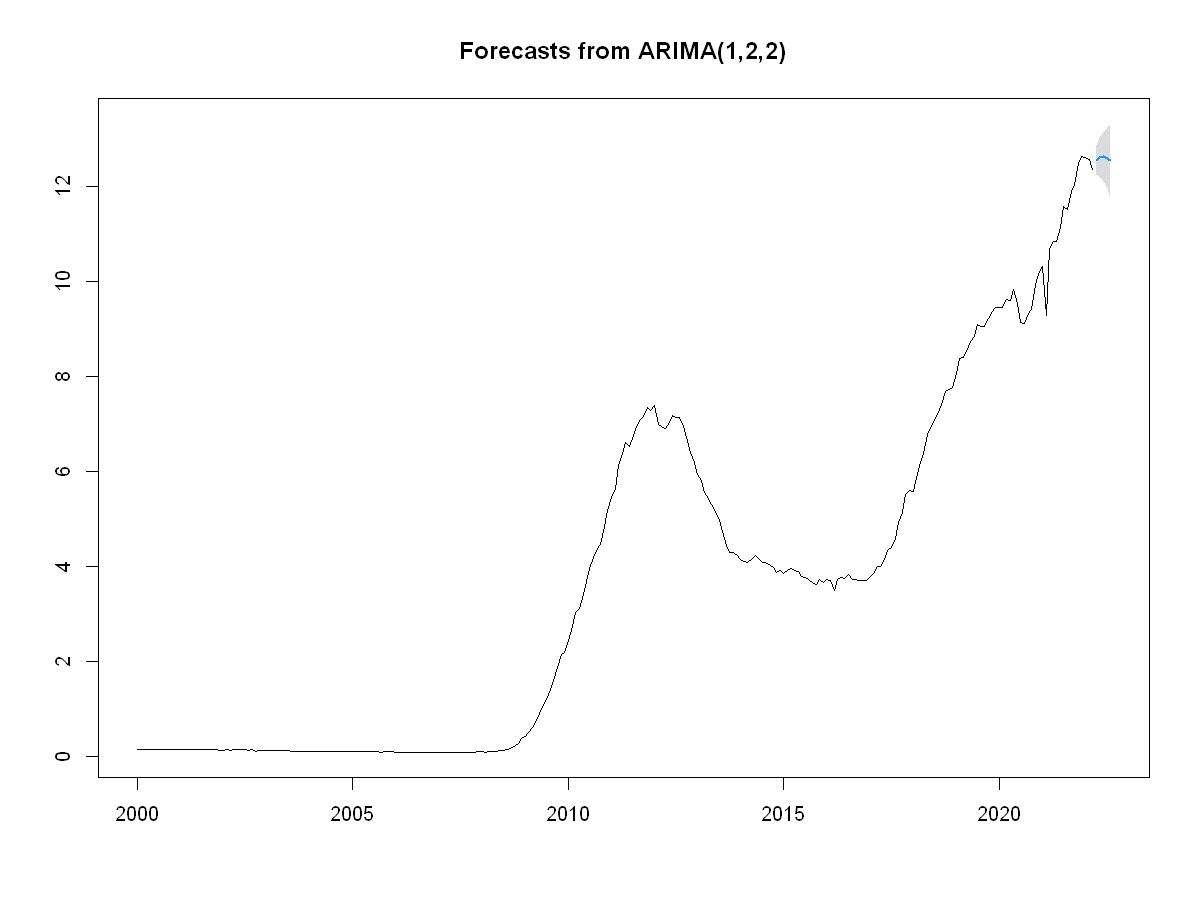

In [25]:
# Color de fondo
par(bg = "white")
# Gráfico
plot(pred)
grafico <- recordPlot()
png("..\\Gráficos\\Predicción.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)
# Métricas de precisión
accuracy(pred, test)
# Mostrar predicción
pred$mean

El análisis ha terminado y el modelo **ajusta apropiadamente**.